In [1]:
# Mean Shift Clustering for Customer Segmentation
# Author: MANIKANDAPRABHU.S


In [2]:
## 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler


In [3]:
## 2. Loading the Dataset
dataset = pd.read_csv("Mall_Customers.csv")
dataset.head()


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
## 3. Exploring the Dataset
print(dataset.shape)
print(dataset.columns)
print(dataset.info())
print(dataset.describe())


(200, 5)
Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000        

In [5]:
## 4. Preparing Features
X = dataset[["Annual Income (k$)", "Spending Score (1-100)"]]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Feature shape:", X_scaled.shape)


Feature shape: (200, 2)


In [6]:
## 5. Applying Mean Shift
from sklearn.cluster import MeanShift, estimate_bandwidth
bandwidth = estimate_bandwidth(X_scaled, quantile=0.2, n_samples=len(X_scaled))
model = MeanShift(bandwidth=bandwidth, bin_seeding=True)
labels = model.fit_predict(X_scaled)
print("Number of clusters:", len(np.unique(labels)))


Number of clusters: 3


In [7]:
## 6. Creating the Clustered Dataset
clustered_data = dataset.copy()
clustered_data["Cluster"] = labels
clustered_data.head()


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,0
1,2,Male,21,15,81,0
2,3,Female,20,16,6,0
3,4,Female,23,16,77,0
4,5,Female,31,17,40,0


In [8]:
## 7. Cluster Summary
print(clustered_data.groupby("Cluster")[["Annual Income (k$)", "Spending Score (1-100)"]].mean())


         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                 44.204918               49.483607
1                 85.325000               82.375000
2                 87.000000               18.631579


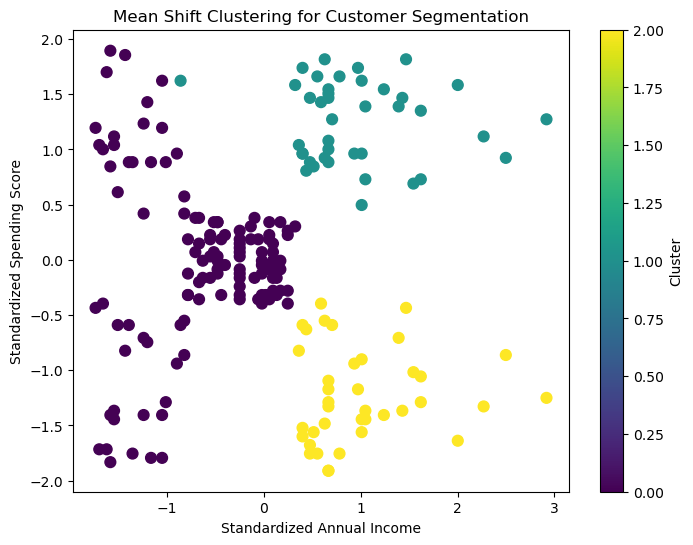

In [9]:
## 8. Data Visualization
plt.figure(figsize=(8,6))
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=labels, cmap="viridis", s=60)
plt.title("Mean Shift Clustering for Customer Segmentation")
plt.xlabel("Standardized Annual Income")
plt.ylabel("Standardized Spending Score")
plt.colorbar(label="Cluster")
plt.show()


In [10]:
## 9. Saving the Trained Model
import pickle
filename = "Mean_Shift_Clustering_Model.sav"
with open(filename, "wb") as file:
    pickle.dump(model, file)
print("Model saved successfully.")


Model saved successfully.


In [11]:
## 10. Conclusion
# The clustering algorithm was applied to group customers using Annual
# Income and Spending Score. The clusters were visualized and the trained
# model was saved for later use.
